# BG/NBD Model for Customer Lifetime Value

The **Beta-Geometric/Negative Binomial Distribution (BG/NBD)** model (Fader, Hardie & Lee, 2005) is the industry-standard probabilistic model for CLV in non-contractual settings — where customers can stop buying at any time without notice.

**Two components:**
- **BG/NBD:** Models purchase frequency (Poisson) and permanent dropout (geometric). Outputs `p_alive` — the calibrated posterior probability a customer is still active.
- **Gamma-Gamma:** Models the monetary value per transaction conditional on activity.

These replace the ML churn classifier, which was limited to AUC 0.72 with heavily overlapping class distributions.

In [10]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

# Install if needed: pip install lifetimes
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix

transactions = pd.read_csv("../data/transactions_2016_2017.csv", low_memory=False)
train        = pd.read_csv("../data/customer_clv_train.csv")
test         = pd.read_csv("../data/customer_clv_test.csv")

transactions["order_date"] = pd.to_datetime(transactions["order_date"])

# Use only purchase rows (positive revenue) — returns don't constitute a purchase event
purchases = transactions[transactions["sale_revenue"] > 0].copy()
print(f"Purchase rows: {len(purchases):,}  |  Unique customers: {purchases['cust_id'].nunique():,}")


Purchase rows: 280,657  |  Unique customers: 145,739


## 1. Compute BG/NBD Summary Statistics

In [11]:
# Observation end = last date in the transaction data
obs_end = purchases["order_date"].max()
print(f"Observation period end: {obs_end.date()}")

# Aggregate to order level (sum items within same order)
# BG/NBD operates on orders (transactions), not individual items
order_level = (
    purchases.groupby(["cust_id","sale_id","order_date"])["sale_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"sale_revenue": "order_revenue"})
)

# summary_data_from_transaction_data computes:
#   frequency     = number of REPEAT purchases (first purchase excluded → min = 0)
#   recency       = time between first and last purchase in chosen units
#   T             = time from first purchase to obs_end
#   monetary_value = mean per-order revenue (for Gamma-Gamma)
bgn_summary = summary_data_from_transaction_data(
    order_level,
    customer_id_col="cust_id",
    datetime_col="order_date",
    monetary_value_col="order_revenue",
    observation_period_end=obs_end,
    freq="W"   # weeks — standard unit for BG/NBD (days cause numerical instability)
)

print(bgn_summary.describe().round(2))
print(f"\nOne-time buyers (frequency=0): {(bgn_summary['frequency']==0).sum():,} "
      f"({100*(bgn_summary['frequency']==0).mean():.1f}%)")


Observation period end: 2017-12-31
       frequency    recency          T  monetary_value
count  145739.00  145739.00  145739.00       145739.00
mean        0.49      10.65      53.68           23.11
std         1.08      22.33      30.12           44.95
min         0.00       0.00       0.00            0.00
25%         0.00       0.00      27.00            0.00
50%         0.00       0.00      51.00            0.00
75%         1.00       3.00      78.00           34.95
max        18.00     104.00     104.00          684.00

One-time buyers (frequency=0): 106,444 (73.0%)


## 2. Fit BG/NBD Model

In [12]:
# BetaGeoFitter estimates 4 parameters: r, alpha (NBD part), a, b (BG part)
# penalizer_coef adds L2 regularization to prevent degenerate solutions
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(
    bgn_summary["frequency"],
    bgn_summary["recency"],
    bgn_summary["T"],
    verbose=True
)
print("\nBG/NBD model parameters:")
print(bgf.summary)


Optimization terminated successfully.
         Current function value: 0.424279
         Iterations: 40
         Function evaluations: 42
         Gradient evaluations: 42

BG/NBD model parameters:
            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.564593  0.007341         0.550205         0.578981
alpha  62.097342  0.979336        60.177844        64.016840
a       0.006224  0.003102         0.000144         0.012305
b       0.125670  0.054102         0.019630         0.231709


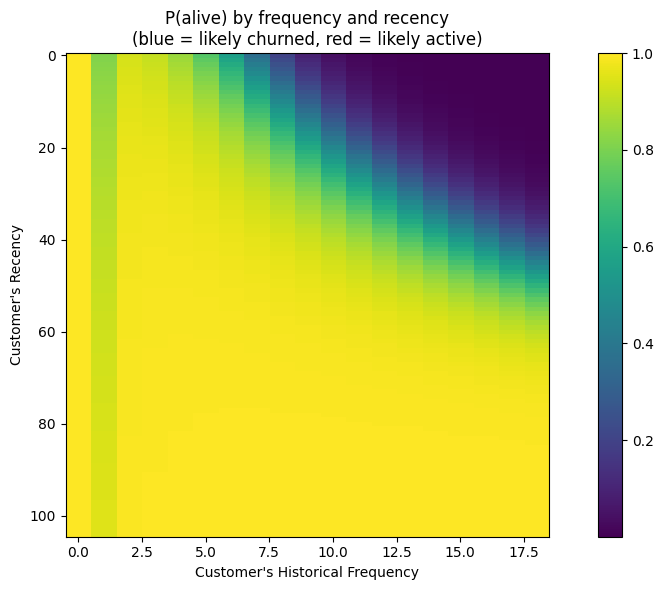

In [13]:
# Visualize the probability-alive matrix
# x-axis: frequency (number of repeat purchases)
# y-axis: recency (weeks since last purchase, relative to T)
# color:  p_alive — blue = likely churned, red = likely still active
plt.figure(figsize=(10, 6))
plot_probability_alive_matrix(bgf)
plt.title("P(alive) by frequency and recency\n(blue = likely churned, red = likely active)")
plt.tight_layout()
plt.show()


## 3. Fit Gamma-Gamma Model (Revenue Component)

In [14]:
# Gamma-Gamma models expected revenue per transaction, conditional on activity
# Only fit on customers with at least one repeat purchase (frequency > 0)
gg_data = bgn_summary[bgn_summary["frequency"] > 0].copy()
print(f"Customers used for Gamma-Gamma fit: {len(gg_data):,}")

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(gg_data["frequency"], gg_data["monetary_value"])
print("\nGamma-Gamma parameters:")
print(ggf.summary)


Customers used for Gamma-Gamma fit: 39,295

Gamma-Gamma parameters:
        coef  se(coef)  lower 95% bound  upper 95% bound
p  11.530811  0.069676        11.394246        11.667376
q   2.113664  0.014448         2.085346         2.141981
v  10.957779  0.071208        10.818211        11.097346


## 4. Extract Per-Customer Features

In [15]:
# p_alive: probability customer has NOT permanently dropped out
bgn_summary["p_alive"] = bgf.conditional_probability_alive(
    bgn_summary["frequency"],
    bgn_summary["recency"],
    bgn_summary["T"]
)

# Expected number of purchases in the next 24 months (104 weeks)
bgn_summary["exp_purchases_24m"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    104,
    bgn_summary["frequency"],
    bgn_summary["recency"],
    bgn_summary["T"]
)

# Expected average revenue per transaction (Gamma-Gamma)
# For customers with frequency=0, GammaGamma returns the global mean (sensible fallback)
bgn_summary["exp_avg_revenue"] = ggf.conditional_expected_average_profit(
    bgn_summary["frequency"],
    bgn_summary["monetary_value"]
)

# BG/NBD CLV estimate = expected purchases × expected revenue per purchase
bgn_summary["bgnbd_clv"] = bgn_summary["exp_purchases_24m"] * bgn_summary["exp_avg_revenue"]

# Also keep raw BG/NBD inputs as features (they encode the purchase pattern)
# bgnbd_frequency, bgnbd_recency_weeks, bgnbd_T_weeks, bgnbd_monetary_value

print(bgn_summary[["p_alive","exp_purchases_24m","exp_avg_revenue","bgnbd_clv"]].describe().round(3))


          p_alive  exp_purchases_24m  exp_avg_revenue   bgnbd_clv
count  145739.000         140737.000       145739.000  140737.000
mean        0.986              0.906          106.494      89.936
std         0.031              0.789           24.947      78.458
min         0.811              0.348           10.202      11.241
25%         0.997              0.457          113.456      49.871
50%         1.000              0.623          113.456      67.075
75%         1.000              0.960          113.456      87.569
max         1.000             11.812          633.749    1203.035


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 5. Evaluate BG/NBD as Standalone Predictor

BG/NBD standalone  MAE: 88.63   Spearman: 0.2940
(This is not the final model — BG/NBD features will be used as inputs to ML)


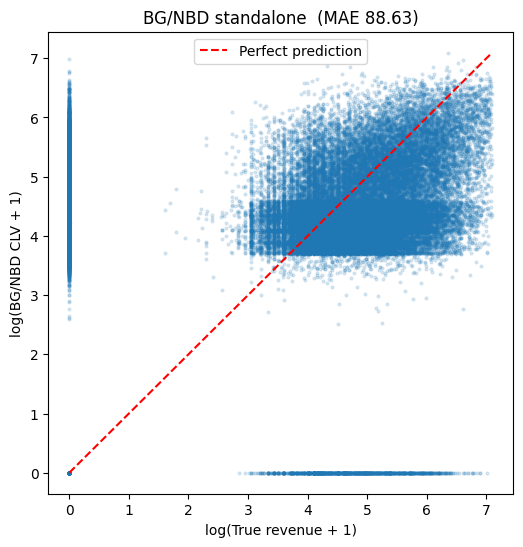

In [16]:
# Evaluate on training set only
train_bgn = train.merge(
    bgn_summary.reset_index()[["cust_id","bgnbd_clv","p_alive","exp_purchases_24m"]],
    on="cust_id", how="left"
)
train_bgn["bgnbd_clv"] = train_bgn["bgnbd_clv"].fillna(0)

mae_bgnbd  = mean_absolute_error(train_bgn["revenue_2018_2019"], train_bgn["bgnbd_clv"])
corr_bgnbd = spearmanr(train_bgn["revenue_2018_2019"], train_bgn["bgnbd_clv"])[0]

print(f"BG/NBD standalone  MAE: {mae_bgnbd:.2f}   Spearman: {corr_bgnbd:.4f}")
print("(This is not the final model — BG/NBD features will be used as inputs to ML)")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(np.log1p(train_bgn["revenue_2018_2019"]),
            np.log1p(train_bgn["bgnbd_clv"]), alpha=0.15, s=4)
lim = max(np.log1p(train_bgn["revenue_2018_2019"]).max(),
          np.log1p(train_bgn["bgnbd_clv"]).max())
plt.plot([0, lim], [0, lim], "r--", label="Perfect prediction")
plt.xlabel("log(True revenue + 1)")
plt.ylabel("log(BG/NBD CLV + 1)")
plt.title(f"BG/NBD standalone  (MAE {mae_bgnbd:.2f})")
plt.legend()
plt.show()


## 6. Merge BG/NBD Features into Customer Features

In [17]:
customer_features_v2 = pd.read_csv("../data/customer_features_v2.csv")

bgnbd_feat = bgn_summary.reset_index().rename(columns={
    "frequency":      "bgnbd_frequency",
    "recency":        "bgnbd_recency_weeks",
    "T":              "bgnbd_T_weeks",
    "monetary_value": "bgnbd_monetary_value",
})[["cust_id","bgnbd_frequency","bgnbd_recency_weeks","bgnbd_T_weeks",
    "bgnbd_monetary_value","p_alive","exp_purchases_24m","exp_avg_revenue","bgnbd_clv"]]

customer_features_v3 = customer_features_v2.merge(bgnbd_feat, on="cust_id", how="left")

# Fill missing (customers not in purchases)
for col in ["p_alive","exp_purchases_24m","bgnbd_clv","bgnbd_frequency"]:
    customer_features_v3[col] = customer_features_v3[col].fillna(0)
for col in ["exp_avg_revenue","bgnbd_monetary_value"]:
    customer_features_v3[col] = customer_features_v3[col].fillna(
        customer_features_v3[col].median()
    )
for col in ["bgnbd_recency_weeks","bgnbd_T_weeks"]:
    customer_features_v3[col] = customer_features_v3[col].fillna(
        customer_features_v3[col].median()
    )

customer_features_v3.to_csv("../data/customer_features_v3.csv", index=False)
print(f"Saved customer_features_v3.csv — {len(customer_features_v3.columns)-1} features, "
      f"{len(customer_features_v3)} customers")


Saved customer_features_v3.csv — 90 features, 145739 customers


In [18]:
import os
os.makedirs("../models", exist_ok=True)

# lifetimes stores a local lambda (generate_new_data) inside the fitted model
# which Python's pickle cannot serialize.  Remove it before saving — it is only
# used for simulation, not for any prediction method we rely on.
for model, path in [(bgf, "../models/bgf_model.pkl"),
                    (ggf, "../models/ggf_model.pkl")]:
    saved_lambda = model.__dict__.pop("generate_new_data", None)
    joblib.dump(model, path)
    if saved_lambda is not None:
        model.generate_new_data = saved_lambda   # restore in-memory object

print("BG/NBD models saved.")


BG/NBD models saved.
